### Prompt Chaining Workflow
- Fundamental and most basic sequential workflow

In [1]:
#import required libraries
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

a:\Learning_LangGraph\lg_venv\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [ ]:
# loading the model and .env
load_dotenv()

model = ChatGroq(model = 'llama-3.3-70b-versatile')

In [ ]:
# state class for the workflow
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str

In [ ]:
#generate outline for the blog
def generate_outline(state: BlogState) -> BlogState:

    prompt = f"Generate a detailed outline for a blog post on the topic: {state['topic']}"
    outline = model.invoke(prompt).content

    state['outline'] = outline
    return state

In [ ]:
# generate the blog based on the topic and outline
def generate_blog(state: BlogState) -> BlogState:

    prompt = f"Write a blog post for the topic: {state['topic']}, based on the following outline: {state['outline']}"
    blog = model.invoke(prompt).content

    state['blog'] = blog
    return state

In [ ]:
# create a state graph and add nodes and edges
graph = StateGraph(BlogState)

#nodes
graph.add_node('generate_outline', generate_outline)
graph.add_node('generate_blog', generate_blog)

#edges
graph.add_edge(START, 'generate_outline')
graph.add_edge('generate_outline', 'generate_blog')
graph.add_edge('generate_blog', END)

#compile graph into a workflow
work_flow = graph.compile()

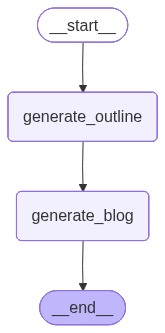

In [ ]:
# visualize the workflow
from IPython.display import Image
Image(work_flow.get_graph().draw_mermaid_png())

In [ ]:
#execute the workflow
initial_state = {'topic' : "The impact of Artificial Intelligence on the job market."}
final_state = work_flow.invoke(initial_state)
print(final_state['outline'])

**Title:** The Impact of Artificial Intelligence on the Job Market: Opportunities, Challenges, and the Future of Work

**I. Introduction**
  * Brief overview of Artificial Intelligence (AI) and its increasing presence in the job market
  * Importance of understanding the impact of AI on employment
  * Thesis statement: AI is transforming the job market, presenting both opportunities and challenges that require attention and strategic planning.

**II. Opportunities Presented by AI in the Job Market**
  * Creation of new job roles and industries related to AI development and implementation
  * Increased efficiency and productivity in various sectors, leading to economic growth
  * Enhanced job satisfaction through automation of repetitive and mundane tasks
  * Examples of industries that have seen positive impacts from AI integration (e.g., healthcare, finance, technology)

**III. Challenges Posed by AI to the Job Market**
  * Job displacement due to automation of tasks previously perfor

In [16]:
print(final_state['blog'])

**The Impact of Artificial Intelligence on the Job Market: Opportunities, Challenges, and the Future of Work**

Artificial Intelligence (AI) has been increasingly present in the job market, transforming the way we work and interact with technology. As AI continues to advance and become more integrated into various industries, it is essential to understand its impact on employment. In this blog post, we will explore the opportunities and challenges presented by AI in the job market, and discuss the future of work in an AI-driven economy. AI is transforming the job market, presenting both opportunities and challenges that require attention and strategic planning.

**Opportunities Presented by AI in the Job Market**

The integration of AI into the job market has created new job roles and industries related to AI development and implementation. For example, the demand for data scientists, machine learning engineers, and AI researchers has increased significantly, leading to the creation of